In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

from src.utils import load_cmapss, add_rul, split_by_engine, get_features_targets
from sklearn.preprocessing import StandardScaler
df = load_cmapss("../data/raw/train_FD001.txt")
df = add_rul(df, cap=140)

train_df, val_df = split_by_engine(df)

X_train, y_train, X_val, y_val = get_features_targets(train_df, val_df)

# scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)


In [2]:

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score


model = LinearRegression()
model.fit(X_train, y_train)

y_preds_lr = model.predict(X_val)

mae = mean_absolute_error(y_val, y_preds_lr)
rmse = root_mean_squared_error(y_val, y_preds_lr)

r2 = r2_score(y_val,y_preds_lr)
print("r2:",r2)
print("MAE:", mae)
print(f"RMSE : {rmse}")


r2: 0.7480997951141044
MAE: 18.824860250167937
RMSE : 23.492424441771934


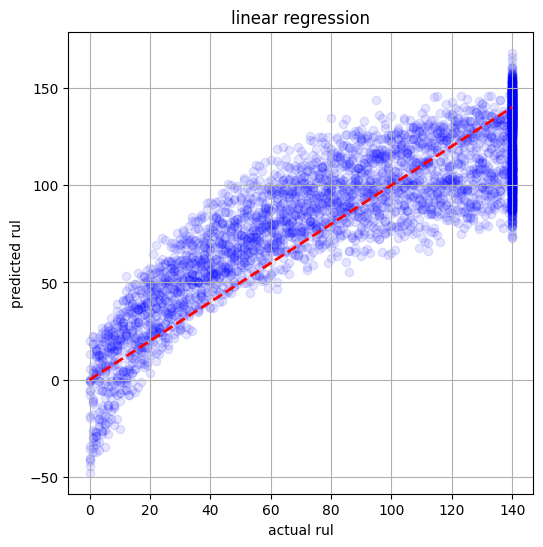

In [3]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.scatter(y_val,y_preds_lr,alpha=0.1,color='blue')
plt.plot([y_val.min(), y_val.max()],
         [y_val.min(), y_val.max()],
         'r--', lw=2)

plt.xlabel('actual rul')
plt.ylabel('predicted rul')
plt.title('linear regression')
plt.grid(True)

plt.show()

In [4]:
from sklearn.tree import DecisionTreeRegressor


model = DecisionTreeRegressor(max_depth=6)
model.fit(X_train, y_train)

y_preds_dr = model.predict(X_val)

mae = mean_absolute_error(y_val, y_preds_dr)
rmse = root_mean_squared_error(y_val, y_preds_dr)
r2 = r2_score(y_val,y_preds_dr)

print("r2:",r2)
print("MAE:", mae)
print(f"RMSE : {rmse}")


r2: 0.7578702397891489
MAE: 17.418022962804677
RMSE : 23.032318861027193


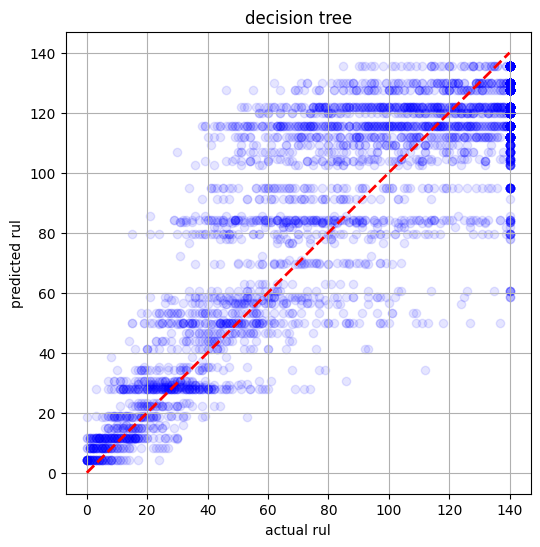

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.scatter(y_val,y_preds_dr,alpha=0.1,color='blue')
plt.plot([y_val.min(), y_val.max()],
         [y_val.min(), y_val.max()],
         'r--', lw=2)

plt.xlabel('actual rul')
plt.ylabel('predicted rul')
plt.title('decision tree')
plt.grid(True)

plt.show()

In [6]:
from sklearn.ensemble import RandomForestRegressor
rand_for_model = RandomForestRegressor(max_depth=None,n_estimators=100,random_state=42)
rand_for_model.fit(X_train,y_train)
y_preds_fr = rand_for_model.predict(X_val)
mae = mean_absolute_error(y_val, y_preds_fr)
rmse = root_mean_squared_error(y_val, y_preds_fr)
r2 = r2_score(y_val,y_preds_fr)

print("r2:",r2)
print("MAE:", mae)
print(f"RMSE : {rmse}")

r2: 0.8115119958987418
MAE: 15.233041769041769
RMSE : 20.32148477569844


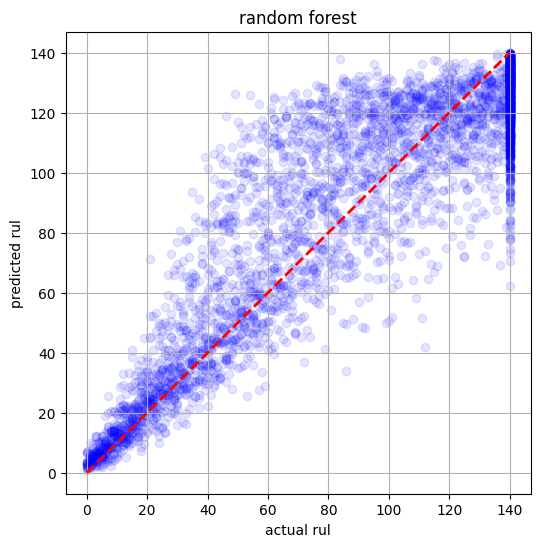

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.scatter(y_val,y_preds_fr,alpha=0.1,color='blue')
plt.plot([y_val.min(), y_val.max()],
         [y_val.min(), y_val.max()],
         'r--', lw=2)

plt.xlabel('actual rul')
plt.ylabel('predicted rul')
plt.title('random forest')
plt.grid(True)

plt.show()

In [8]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.07,
    max_depth=3,
    random_state=42
)

gbr.fit(X_train, y_train)
y_preds_gbr = gbr.predict(X_val)

mae = mean_absolute_error(y_val, y_preds_gbr)
rmse = root_mean_squared_error(y_val, y_preds_gbr)
r2 = r2_score(y_val, y_preds_gbr)


print("R2:", r2)
print("MAE:", mae)
print("RMSE:", rmse)


R2: 0.8139868097817853
MAE: 15.151342058882667
RMSE: 20.187635233122993


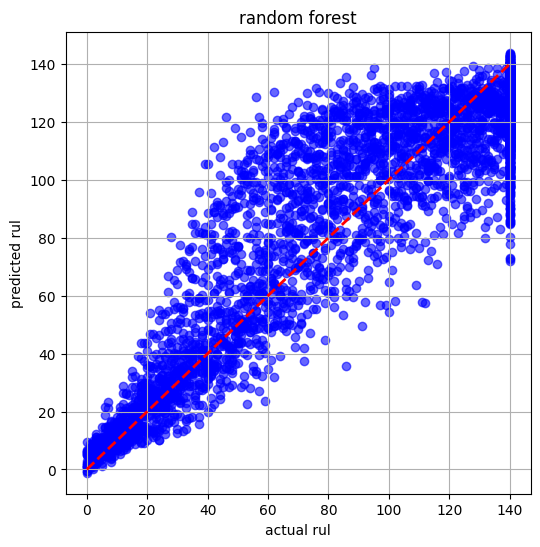

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.scatter(y_val,y_preds_gbr,alpha=0.6,color='blue')
plt.plot([y_val.min(), y_val.max()],
         [y_val.min(), y_val.max()],
         'r--', lw=2)

plt.xlabel('actual rul')
plt.ylabel('predicted rul')
plt.title('random forest')
plt.grid(True)

plt.show()

In [11]:
import pickle

preds = {
    "y_val": y_val,
    "Linear Regression": y_preds_lr,
    "Decision Tree": y_preds_dr,
    "Random Forest": y_preds_fr,
    "Gradient Boosting": y_preds_gbr
}

with open("../data/processed/predictions.pkl", "wb") as f:
    pickle.dump(preds, f)
